From https://eloy.readthedocs.io/en/latest/photometry/

In [1]:

from astropy.io import fits
from astropy.time import Time

from dateutil import parser
from glob import glob

images = glob("data/*.fits.fz")

# photometry on the stacked image
#file = "output/stack_image.fits"

file = images[0]

# get observation time from FITS header (SCI extension)
def observation_time(header):
    date_str = header["DATE-OBS"]
    return Time(parser.parse(date_str))


detected FWHM: 3.988022110548593


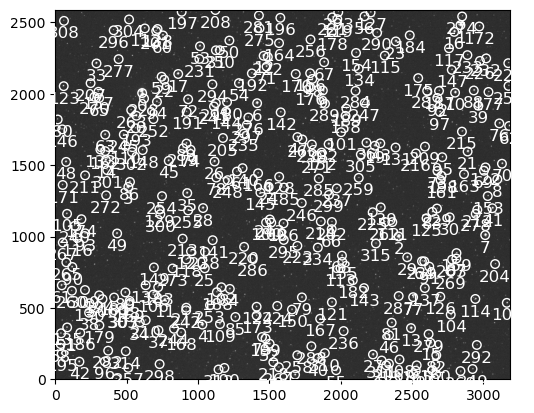

In [16]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

from eloy import psf, detection, utils
from eloy import viz

# calibration sequence

#trim = 10


def calibration_sequence(data, header):

    # trimming
    # todo - so calibration stars are not selected from the margin
    
    # detection
    regions = detection.stars_detection(data)

    # stars coords and cutouts
    region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])

    #note: cutouts are the small images of the stars, which are used to model the PSF
    cutouts = utils.cutout(data, region_coords, (50, 50))

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    # note epsf is the empirical PSF, which is the median of the normalized cutouts
    epsf = np.nanmedian(cutouts_normalized, 0)
    psf_params = psf.fit_gaussian(epsf)
    fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
        [psf_params["sigma_x"], psf_params["sigma_y"]]
    )
    
    print("detected FWHM:", fwhm)

    del (
        cutouts_normalized,
        regions,
        cutouts,
        epsf,
    )

    return region_coords, fwhm


# and create a calibration sequence from the reference image

data = fits.getdata(file)
header = fits.getheader(file, extname="sci")

centroid_coords, fwhm = calibration_sequence(data, header)

plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
viz.plot_marks(*centroid_coords.T, color="w", label=True, ms=30)


In [14]:
data

array([[205.08223, 210.68604, 197.74779, ..., 209.2726 , 205.65805,
        202.57486],
       [203.5914 , 204.31313, 199.76512, ..., 203.41893, 204.41704,
        217.10034],
       [205.8918 , 203.40259, 199.87032, ..., 204.35869, 203.45387,
        208.97046],
       ...,
       [204.40573, 203.39185, 207.24681, ..., 206.2928 , 206.24573,
        211.3844 ],
       [205.22847, 207.63922, 205.23723, ..., 207.0039 , 207.43741,
        208.83836],
       [209.5377 , 205.68796, 207.29446, ..., 209.94559, 207.70589,
        208.03465]], shape=(2590, 3184), dtype=float32)

In [20]:

from tqdm.auto import tqdm
from skimage.transform import AffineTransform
from collections import defaultdict
from eloy import centroid, photometry

n_stars = 300

# relative apertures radii to use for the aperture photometry, to be scaled by the FWHM of the PSF
# TODO: rewrite this with a simpler single aperature scale
# TODO: rewrite for vanilla photutils

relative_apertures_radii = np.linspace(0.1, 5, 40)


### aperture photometry

# a list of radii to use for the aperture photometry, scaled by the FWHM of the PSF
apertures_radii = relative_apertures_radii * fwhm

# for each star, calculate the flux in each aperture
flux_ap = photometry.aperture_photometry(
    data, centroid_coords, apertures_radii
)

### annulus background correction

# create an array of the inner and outer radii of the annulus to use for the background estimation,
# scaled by the FWHM of the PSF
annulus_radii = (np.max(apertures_radii), 8 * fwhm)
aperture_area = np.pi * apertures_radii**2

# find the background for each star using the annulus method
bkg = photometry.annulus_sigma_clip_median(
    data, centroid_coords, *annulus_radii
)

# multiply the background by the area of each aperture 
# to get the total background flux for each star, for each aperture size
bkg = bkg[:, None] * aperture_area[None, :]


jd = observation_time(header).jd

# measurements data
#data["bkg"]=bkg
#data["fluxes"]=flux
#data["fwhm"]=fwhm
#data["time"]=jd


/tmp/ipykernel_118484/3341102908.py:6: RuntimeWarning: invalid value encountered in log10
  inst_mags = 2.5*np.log10(flux)


Text(0, 0.5, 'instrumental magnitudes')

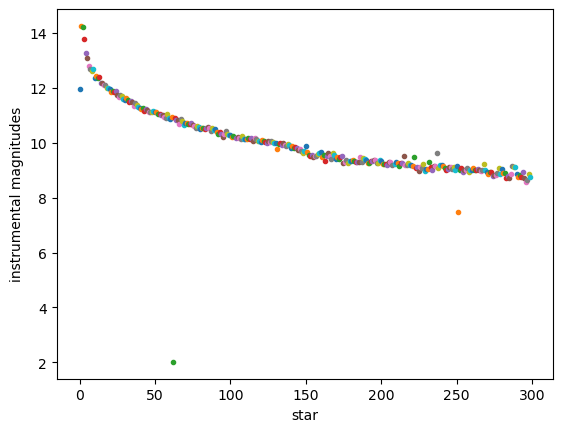

In [22]:
import matplotlib.pyplot as plt

# we remove the background from the annulus aperture
flux = flux_ap-bkg

inst_mags = 2.5*np.log10(flux) 

#plot some random photometry data
for i in range(0,n_stars):
    plt.plot( i, inst_mags[ i,19], ".")

plt.xlabel("star")
plt.ylabel("instrumental magnitudes")


Target index is 2
[2405.74074074 1000.27441077]
<SkyCoord (ICRS): (ra, dec) in deg
    (297.71101239, 48.08258218)>
<SkyCoord (ICRS): (ra, dec) in deg
    (297.70936374, 48.0808615)>


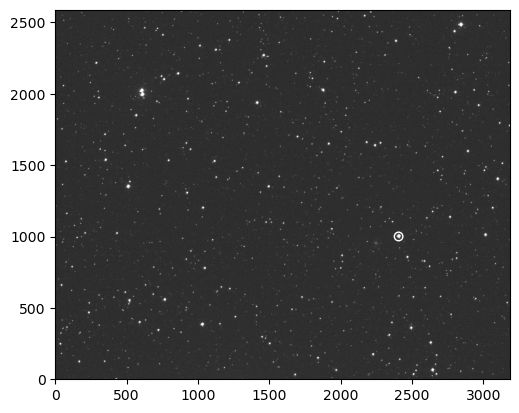

In [23]:

# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform centroid_coords to skycoords
wcs = WCS(header)
centroid_radec = wcs.pixel_to_world(*centroid_coords.T)

mast = Mast()
target_radec = mast.resolve_object("HAT-P-11")
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{centroid_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
viz.plot_marks(centroid_coords[target_index][0],centroid_coords[target_index][1], color="w", ms=30)

target = centroid_coords[target_index]

In [107]:
# cross match target stars from GAIA DR3 Synthetic Photometry Catalogue

from astroquery.gaia import Gaia
from astropy.table import QTable
from astropy.wcs.utils import pixel_to_skycoord
import requests


(img_width, img_height) = wcs.pixel_shape
img_center_coord = wcs.pixel_to_world(img_width/2, img_height/2)
img_top_left = wcs.pixel_to_world(0, 0)
img_bottom_right = wcs.pixel_to_world(img_width, img_height)

img_coord_width = img_top_left.separation(wcs.pixel_to_world(img_width,0))
img_coord_height = img_top_left.separation(wcs.pixel_to_world(0, img_height))

where_min_magnitude = "src.phot_g_mean_mag < 16"

where_box_search = f"""1 = CONTAINS(
            POINT(src.ra, src.dec), 
            BOX({img_center_coord.ra.deg}, {img_center_coord.dec.deg}, {img_coord_width.deg}, {img_coord_height.deg})
        )"""

#where_box_search = f"""src.ra BETWEEN {img_top_left.ra.deg}) AND {img_bottom_right.ra.deg}
#        AND src.dec BETWEEN {img_top_left.dec.deg} AND {img_bottom_right.dec.deg}
#"""


query = f"""
SELECT src.ra, src.dec, gspc.*
    FROM gaiadr3.synthetic_photometry_gspc AS gspc
    JOIN gaiadr3.gaia_source AS src 
        ON gspc.source_id = src.source_id
    
    WHERE {where_min_magnitude} 
        AND {where_box_search}
    ;
"""

print(query)


SELECT src.ra, src.dec, gspc.*
    FROM gaiadr3.synthetic_photometry_gspc AS gspc
    JOIN gaiadr3.gaia_source AS src 
        ON gspc.source_id = src.source_id

    WHERE src.phot_g_mean_mag < 16 
        AND 1 = CONTAINS(
            POINT(src.ra, src.dec), 
            BOX(297.66240421754577, 47.95932113948957, 0.4689405899749046, 0.3815674912574227)
        )
    ;



In [108]:
job = Gaia.launch_job(query)

results = job.get_results()
results


ra,dec,source_id,c_star,u_jkc_flux,u_jkc_flux_error,u_jkc_mag,u_jkc_flag,b_jkc_flux,b_jkc_flux_error,b_jkc_mag,b_jkc_flag,v_jkc_flux,v_jkc_flux_error,v_jkc_mag,v_jkc_flag,r_jkc_flux,r_jkc_flux_error,r_jkc_mag,r_jkc_flag,i_jkc_flux,i_jkc_flux_error,i_jkc_mag,i_jkc_flag,u_sdss_flux,u_sdss_flux_error,u_sdss_mag,u_sdss_flag,g_sdss_flux,g_sdss_flux_error,g_sdss_mag,g_sdss_flag,r_sdss_flux,r_sdss_flux_error,r_sdss_mag,r_sdss_flag,i_sdss_flux,i_sdss_flux_error,i_sdss_mag,i_sdss_flag,z_sdss_flux,z_sdss_flux_error,z_sdss_mag,z_sdss_flag,y_ps1_flux,y_ps1_flux_error,y_ps1_mag,y_ps1_flag,f606w_acswfc_flux,f606w_acswfc_flux_error,f606w_acswfc_mag,f606w_acswfc_flag,f814w_acswfc_flux,f814w_acswfc_flux_error,f814w_acswfc_mag,f814w_acswfc_flag
deg,deg,,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,
float64,float64,int64,float32,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16
297.60668096155604,47.860555007036965,2086414817994429184,-0.00039434433,1.6459068e-16,1.4442619e-18,13.610087,1,2.1961694e-16,5.3428325e-19,13.674835,1,1.9607852e-16,3.5152066e-19,13.182825,1,1.5816497e-16,2.2605502e-19,12.875424,1,1.1143346e-16,1.3182171e-19,12.561261,1,8.264772e-29,6.966353e-31,14.419423,0,1.6211291e-28,3.4100257e-31,13.354756,0,2.1820488e-28,3.208418e-31,13.044939,0,2.3514772e-28,2.8332867e-31,12.952348,0,2.3783918e-28,3.4584744e-31,12.935692,0,2.3810038e-28,6.3836533e-31,12.9648,0,1.7740029e-16,1.8201777e-19,13.039515,1,1.09507324e-16,1.2338198e-19,12.566192,1
297.46485399267965,47.91719173346202,2086427771615750656,-0.005532503,--,--,--,0,9.821735e-18,5.960228e-20,17.048529,1,1.2164858e-17,4.0243245e-20,16.201132,1,1.1382833e-17,2.8683803e-20,15.732574,1,8.880962e-18,2.1258081e-20,15.30765,1,--,--,--,0,8.3733115e-30,3.535105e-32,16.572058,1,1.5274502e-29,4.513337e-32,15.932182,1,1.8281795e-29,4.7176226e-32,15.725653,1,1.9804345e-29,6.9001236e-32,15.634499,1,2.0467517e-29,1.7358513e-31,15.629037,1,1.1862483e-17,2.561051e-20,15.976461,1,8.745456e-18,2.0228972e-20,15.310344,1
297.45780467283043,47.920874479440755,2086427840335225856,-0.005194664,8.397942e-18,2.322602e-19,16.840668,1,1.3767105e-17,6.631437e-20,16.681894,1,1.4717396e-17,4.464705e-20,15.994323,1,1.2755885e-17,3.2393436e-20,15.608924,1,9.513764e-18,2.2386026e-20,15.232919,1,4.260308e-30,1.211141e-31,17.638897,1,1.1041392e-29,4.0091425e-32,16.27174,1,1.7308578e-29,5.0785006e-32,15.796447,1,1.9848852e-29,5.056566e-32,15.636361,1,2.0903335e-29,7.2056546e-32,15.575861,1,2.1353112e-29,1.8227695e-31,15.583047,1,1.3790065e-17,2.8324328e-20,15.812984,1,9.3784555e-18,2.1521765e-20,15.234471,1
297.4540758991062,47.92962053895756,2086427874694966144,0.0127648115,1.0260789e-17,2.6981711e-19,16.623148,1,1.4132943e-17,6.982548e-20,16.653418,1,1.4945274e-17,4.59808e-20,15.97764,1,1.3066359e-17,3.2663886e-20,15.582813,1,9.907423e-18,2.3530642e-20,15.188898,1,5.1874784e-30,1.3908168e-31,17.42511,1,1.12543575e-29,4.107667e-32,16.250998,1,1.7656136e-29,5.170314e-32,15.77486,1,2.0564276e-29,5.354536e-32,15.597917,1,2.1920196e-29,7.474185e-32,15.524289,1,2.2615183e-29,1.8799555e-31,15.5206995,1,1.4059665e-17,2.9424582e-20,15.791963,1,9.753671e-18,2.2543444e-20,15.191879,1
297.47562584990635,47.96151729225025,2086428012133943296,0.00039052963,3.9091954e-17,5.104381e-19,15.170881,1,6.069865e-17,1.5563649e-19,15.071053,1,6.357205e-17,1.2115329e-19,14.405

centroid_x,centroid_y,centroid_ra,centroid_dec,gaia_match_err,ra,dec,source_id,c_star,u_jkc_flux,u_jkc_flux_error,u_jkc_mag,u_jkc_flag,b_jkc_flux,b_jkc_flux_error,b_jkc_mag,b_jkc_flag,v_jkc_flux,v_jkc_flux_error,v_jkc_mag,v_jkc_flag,r_jkc_flux,r_jkc_flux_error,r_jkc_mag,r_jkc_flag,i_jkc_flux,i_jkc_flux_error,i_jkc_mag,i_jkc_flag,u_sdss_flux,u_sdss_flux_error,u_sdss_mag,u_sdss_flag,g_sdss_flux,g_sdss_flux_error,g_sdss_mag,g_sdss_flag,r_sdss_flux,r_sdss_flux_error,r_sdss_mag,r_sdss_flag,i_sdss_flux,i_sdss_flux_error,i_sdss_mag,i_sdss_flag,z_sdss_flux,z_sdss_flux_error,z_sdss_mag,z_sdss_flag,y_ps1_flux,y_ps1_flux_error,y_ps1_mag,y_ps1_flag,f606w_acswfc_flux,f606w_acswfc_flux_error,f606w_acswfc_mag,f606w_acswfc_flag,f814w_acswfc_flux,f814w_acswfc_flux_error,f814w_acswfc_mag,f814w_acswfc_flag
,,deg,deg,deg,deg,deg,,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,
float64,float64,float64,float64,float64,float64,float64,int64,float32,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16
511.9686888454012,1347.7045009784736,297.6721733591111,47.800169544263376,0.0002460465913732357,297.4540758991062,47.92962053895756,2086427874694966144,0.0127648115,1.0260789205374246e-17,2.6981711343048298e-19,16.62314796447754,1,1.4132943248285014e-17,6.98254820563835e-20,16.653417587280273,1,1.494527431448149e-17,4.5980798902714857e-20,15.977640151977539,1,1.3066359195666276e-17,3.2663885743078685e-20,15.582813262939453,1,9.907422610775268e-18,2.353064209540832e-20,15.188898086547852,1,5.187478387353906e-30,1.390816821577946e-31,17.42510986328125,1,1.125435745217379e-29,4.10766685517019e-32,16.25099754333496,1,1.7656135797938426e-29,5.170313748313538e-32,15.774860382080078,1,2.056427647226823e-29,5.354536047480056e-32,15.597916603088379,1,2.1920195852325914e-29,7.474185109894103e-32,15.52428913116455,1,2.2615182719085738e-29,1.8799555374805306e-31,15.520699501037598,1,1.4059664972180166e-17,2.942458184083567e-20,15.791962623596191,1,9.753671241597586e-18,2.2543444039591764e-20,15.191879272460938,1
1030.9061784897026,382.5446224256293,297.87312999562755,47.88890571391907,0.00018693536266724023,297.47562584990635,47.96151729225025,2086428012133943296,0.00039052963,3.909195356177015e-17,5.104381116590826e-19,15.170881271362305,1,6.069865231548408e-17,1.5563648794429567e-19,15.071052551269531,1,6.357205277036668e-17,1.2115329276091476e-19,14.405734062194824,1,5.5129543036185063e-17,8.536098086059212e-20,14.019739151000977,1,4.117463221677861e-17,5.479004624420586e-20,13.64222526550293,1,1.963820660020455e-29,2.579089383740847e-31,15.979745864868164,0,4.814492036199575e-29,1.003998776343817e-31,14.672924041748047,1,7.492035400683374e-29,1.2606473966947242e-31,14.20560073852539,1,8.576418820661562e-29,1.18037982289374e-31,14.04743480682373,1,9.035384176442946e-29,1.6220499610202893e-31,13.986533164978027,1,9.254986532792378e-29,3.470497077723639e-31,13.990760803222656,1,5.951248855197284e-17,6.856787025727026e-20,14.225379943847656,1,4.0524527812316037e-17,5.111972954403443e-20,13.64550495147705,1
1414.2789968652037,1934.219435736677,297.52595785504013,47.92468758548704,7.147143999610474e-05,297.8578602382935,47.83502599389724,2086504462550115712,-0.002838254,———,———,———,0,1.7507512583978796e-17,8.54258369904951e-20,16.42093849182129,1,2.835251215903903e-17,6.685274356888423e-20,15.282421112060547,1,3.

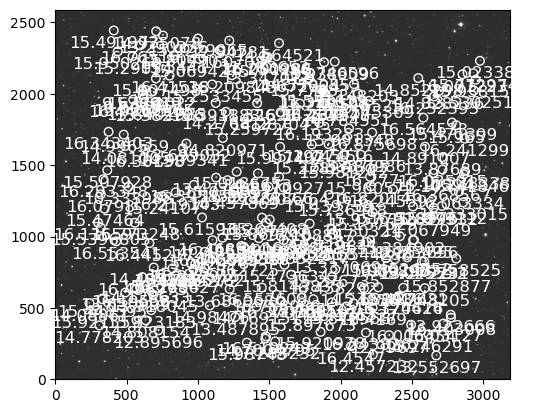

In [ ]:
from astropy.coordinates import match_coordinates_sky
from astropy.wcs.utils import pixel_to_skycoord
from astropy.table import hstack

centroid_skycoords = pixel_to_skycoord(*centroid_coords.T, wcs)

gaia_table=results

#extract coordinates of catalog stars
gaia_skycoords = SkyCoord(gaia_table["ra"], gaia_table["dec"], frame="icrs")
gaia_match = match_coordinates_sky(centroid_skycoords, gaia_skycoords)

centroid_table = QTable([centroid_coords.T[0], centroid_coords.T[1],centroid_skycoords.ra, centroid_skycoords.dec, gaia_match[1]], 
                        names=["centroid_x", "centroid_y", "centroid_ra","centroid_dec", "gaia_match_err"])


catalog_table = hstack([centroid_table, gaia_table])#, panstarrs_table])
catalog_table_masked = catalog_table[(catalog_table["gaia_match_err"]<2*u.arcsec) ]
display(catalog_table_masked)



catalog_skycoords = SkyCoord(ra=catalog_table_masked["ra"],dec=catalog_table_masked["dec"], frame="icrs")
#print(catalog_skycoords)
catalog_pixels = wcs.world_to_pixel(catalog_skycoords.unmasked)

plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
viz.plot_marks(catalog_pixels[0], catalog_pixels[1], label=catalog_table_masked["g_sdss_mag"],color="w", ms=30)




In [22]:
# cross match target stars from the PAN-STARRS survey
# retrieve PAN-STARRS data for this field

from astroquery.vizier import Vizier
from astropy.table import QTable
from astropy.wcs.utils import pixel_to_skycoord

# select the PanSTARRS 1 catalog in Vizier
# "II/349/ps1_dr2" is the Vizier designation for PanSTARRS DR2
CAT_PANSTARRS="II/389/ps1_dr2"
CAT_APASS="II/336"

v=Vizier(row_limit=-1, catalog=[CAT_PANSTARRS, CAT_APASS])


# get the pixel shape of the image
(img_width, img_height) = wcs.pixel_shape
img_center_coord = wcs.pixel_to_world(img_width/2, img_height/2)
img_radius = img_center_coord.separation(wcs.pixel_to_world(0,0))

print(img_center_coord, img_radius)

# Query Pan-STARRS DR2 
print("Querying Vizier for the image area...")
result = v.query_region(img_center_coord,radius=img_radius)

'''
centroid_skycoords = pixel_to_skycoord(*centroid_coords.T, wcs)

# create table from these values
centroid_table = QTable([centroid_skycoords.ra, centroid_skycoords.dec], names=["_RAJ2000","_DEJ2000"])

result=v.query_region(centroid_table, radius=5*u.arcsec)
'''
display(result)



<SkyCoord (ICRS): (ra, dec) in deg
    (297.66240422, 47.95932114)> 0d18m08.28786598s
Querying Vizier for the image area...


TableList with 2 tables:
	'0:II/389/ps1_dr2' with 35 column(s) and 30139 row(s) 
	'1:II/336/apass9' with 19 column(s) and 941 row(s) 

centroid_x,centroid_y,centroid_ra,centroid_dec,panstarrs_match_err,apass_match_err,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,Field,nobs,mobs,B-V,e_B-V,Vmag,e_Vmag,Bmag,e_Bmag,g'mag,e_g'mag,r'mag,e_r'mag,i'mag,e_i'mag
,,deg,deg,deg,deg,deg,deg,arcsec,arcsec,,,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag
float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,int64,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
2838.9953917050693,2480.9231950844855,297.3770220380741,48.126157556545074,6.858428253384967e-05,0.00028904996761576376,297.376994,48.126446,0.493,0.208,20122236,5,19,1.057,0.154,9.385,0.015,10.442,0.154,9.879,0.186,9.111,0.000,8.796,0.054
511.9686888454012,1347.7045009784736,297.6721733591111,47.800169544263376,0.00023129692753297523,0.0003118914733651027,297.671777,47.800332,0.434,0.492,20122236,6,24,0.686,0.158,9.968,0.012,10.654,0.158,10.258,0.032,9.747,0.030,9.516,0.053
1030.9061784897026,382.5446224256293,297.87312999562755,47.88890571391907,0.0001504302558618437,0.0002476832449170454,297.872762,47.888927,0.455,0.311,20122236,5,18,0.451,0.177,10.616,0.023,11.067,0.175,10.791,0.069,10.580,0.048,10.434,0.096
2642.767088607595,62.82025316455696,297.9124321609073,48.12948860300106,0.0002421248071401654,0.00015610679226675322,297.912278,48.129606,0.640,0.525,20122236,6,23,0.034,0.203,11.073,0.136,11.107,0.151,10.970,0.065,11.174,0.185,———,———
1414.2789968652037,1934.219435736677,297.52595785504013,47.92468758548704,3.303934399620489e-05,8.3800810046852e-05,297.525850,47.924730,0.497,0.296,20122236,6,27,0.505,0.224,11.136,0.052,11.641,0.218,11.301,0.149,10.983,0.080,10.870,0.098
3012.4848484848485,1009.5286195286195,297.6970215068127,48.17145571568223,0.00016339547457221002,0.00014585845280937982,297.696803,48.171462,0.478,0.244,20122236,6,27,0.289,0.189,11.373,0.102,11.662,0.159,11.423,0.120,11.305,0.117,11.345,0.240
3097.710344827586,1401.0275862068966,297.6091952945055,48.1787642003065,0.00013379976979988994,0.00013709945202019635,297.609026,48.178842,0.404,0.146,20122236,6,27,1.392,0.190,10.953,0.057,12.345,0.181,11.586,0.139,10.507,0.092,10.101,0.089
1875.0240240240241,2023.3213213213214,297.4971393264474,47.991060468143075,0.0001245886449290125,0.00014553172140727784,297.497022,47.991183,0.620,0.264,20122236,5,25,0.105,0.231,11.354,0.053,11.459,0.224,11.331,0.150,11.431,0.121,11.482,0.134


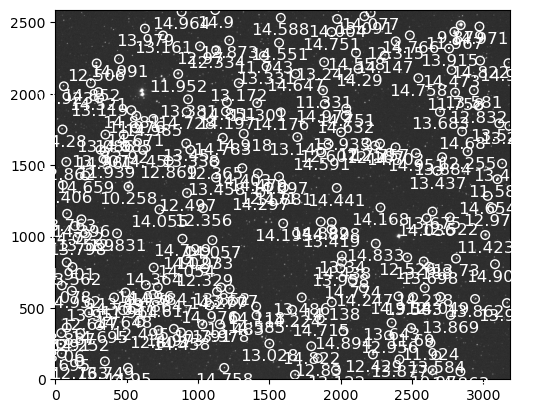

In [31]:
from astropy.coordinates import match_coordinates_sky
from astropy.wcs.utils import pixel_to_skycoord
from astropy.table import hstack

#centroid_wcscoords = wcs.all_pix2world(centroid_coords.T[0], centroid_coords.T[1], 1)
#centroid_skycoords = SkyCoord(ra=centroid_wcscoords[0], dec=centroid_wcscoords[1], unit=u.deg, frame="icrs")

centroid_skycoords = pixel_to_skycoord(*centroid_coords.T, wcs)

#extract coordinates of catalog stars
apass_all = result[1]
apass_skycoords = SkyCoord(apass_all["RAJ2000"], apass_all["DEJ2000"])
apass_match = match_coordinates_sky(centroid_skycoords, apass_skycoords)

panstarrs_all = result[0]
panstarrs_skycoords = SkyCoord(panstarrs_all["RAJ2000"], panstarrs_all["DEJ2000"])
panstarrs_match = match_coordinates_sky(centroid_skycoords, panstarrs_skycoords)

apass_table = apass_all[apass_match[0]]
panstarrs_table = panstarrs_all[panstarrs_match[0]]

i=3

centroid_table = QTable([centroid_coords.T[0], centroid_coords.T[1],centroid_skycoords.ra, centroid_skycoords.dec, panstarrs_match[1], apass_match[1]], 
                        names=["centroid_x", "centroid_y", "centroid_ra","centroid_dec", "panstarrs_match_err", "apass_match_err"])
#centroid_table = QTable([centroid_skycoords.ra, centroid_skycoords.dec, panstarrs_match[1]], 
#                        names=["centroid_ra","centroid_dec", "panstarrs_match_err"])


catalog_table = hstack([centroid_table, apass_table])#, panstarrs_table])
catalog_table_masked = catalog_table[(catalog_table["apass_match_err"]<2*u.arcsec) ]#& (catalog_table["apass_match_err"]<5*u.arcsec)]
catalog_table_masked = catalog_table_masked[catalog_table_masked["g\'mag"]<15*u.mag]
display(catalog_table_masked)


plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")

catalog_skycoords = SkyCoord(ra=catalog_table_masked["RAJ2000"],dec=catalog_table_masked["DEJ2000"], frame="icrs")
#print(catalog_skycoords)
catalog_pixels = wcs.world_to_pixel(catalog_skycoords.unmasked)

viz.plot_marks(catalog_pixels[0], catalog_pixels[1], label=catalog_table_masked["g\'mag"],color="w", ms=30)




In [27]:
print(wcs.pixel_shape)
(img_width, img_height) = wcs.pixel_shape
img_center_coord = wcs.pixel_to_world(img_width/2, img_height/2)
img_radius = img_center_coord.separation(wcs.pixel_to_world(0,0))

print(img_center_coord)
print(img_radius)


(3184, 2590)
<SkyCoord (ICRS): (ra, dec) in deg
    (297.66240422, 47.95932114)>
0d18m08.28786598s
